## Install or Import Packages

In [1]:
# Install grad-cam package (only for this notebook)
%pip install grad-cam

Note: you may need to restart the kernel to use updated packages.


In [2]:
%cd ..

/common/wut4/workspace/OCT


In [3]:
import os, torch
import numpy as np
from PIL import Image
from matplotlib import pyplot as plt

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

from model import ResNetClassifier
from dataloader import data_collector, data_split, get_data_transforms

## Load Model

In [4]:
# 1000x1000
save_dir = os.path.join('results', '20240321-194738')

In [5]:
model = ResNetClassifier(num_classes=5)
model = model.load_from_checkpoint(os.path.join(save_dir, 'bestmodel.ckpt'), map_location=torch.device('cpu'))
model.eval()

ResNetClassifier(
  (resnet): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, t

In [6]:
# target layer for ResNet 18
target_layers = [model.resnet.layer4[-1]]

In [7]:
cam = GradCAM(model=model, target_layers=target_layers)

## Load Data

In [8]:
class2index = {
    'P20_11_7_2023': 0,
    'P40_11_24_2023': 1, 
    'P60_12_13_2023': 2,
    'P90_1_10_2024': 3,
    'P120_2_8-2024': 4}

In [9]:
df = data_collector(data_dir='./data/OCT-Tiff', remove_same_case=True)
_, _, test_df = data_split(df, verbose=False)

In [10]:
data_transforms = get_data_transforms(input_shape=(1000, 1000))['val']

In [11]:
idx = 2000

In [12]:
y = class2index[test_df.iloc[idx]['date']]
image = Image.open(test_df.iloc[idx]['path'])
X = data_transforms(image).unsqueeze(0)

Data information: need to justify if this is a correct case

In [13]:
print(f"Data folder: {df.iloc[idx]['path']}")
output = model(X)
pred = np.argmax(output.detach().numpy())
print(f"Ground true: {y}, prediction: {pred}, output: {output}")

Data folder: ./data/OCT-Tiff/P60_12_13_2023/AI032_OD_V_3x3_0_0000066_12_13_2023/AI032_OD_V_3x3_0_0000066_Structure_0283.TIFF
Ground true: 2, prediction: 2, output: tensor([[ -4.5116,   0.7655,   7.4664,  -8.3821, -11.5843]],
       grad_fn=<AddmmBackward0>)


In [14]:
grayscal_cam = cam(input_tensor=X, targets=None)

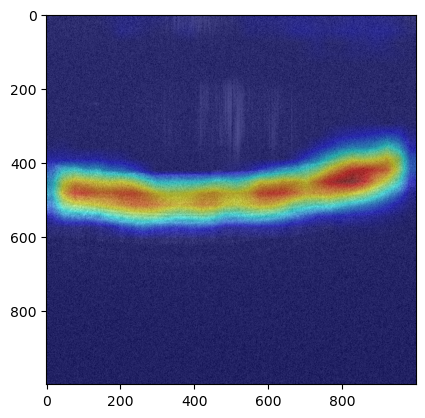

In [15]:
visualization = show_cam_on_image(np.transpose(X[0].numpy(), (1, 2, 0)), grayscal_cam[0], use_rgb=True)
plt.imshow(visualization)

In [16]:
save_name = df.iloc[idx]['date'].split('_')[0] + '_' + df.iloc[idx]['path'].split('/')[-1].replace('TIFF', 'png')
plt.imsave(save_name, visualization)